In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ryrMC import *
from params import RestrepoParams
from utils import _rho, _Mhat

In [2]:
cs = 0.2
cjsr = 950.
N = 100
params = RestrepoParams(Ku=1.4e-4, h=2.5)

log_pi = Po_stationary_logp(N, cs, cjsr, params)
Pos = np.arange(0, 101)

kr = params.tau_ps * params.Jmax / params.vp
cps = (cs + kr * cjsr * Pos) / (1 + kr * Pos)

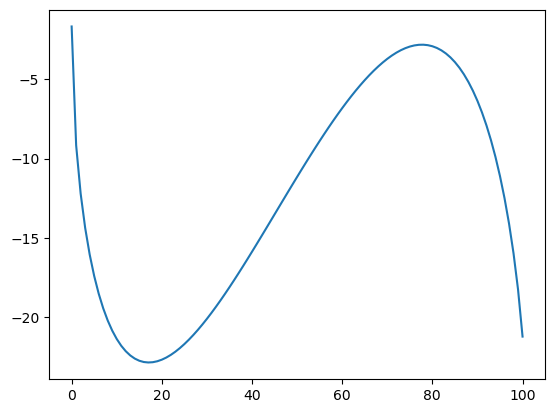

In [3]:
plt.plot(Pos, log_pi)
plt.show()

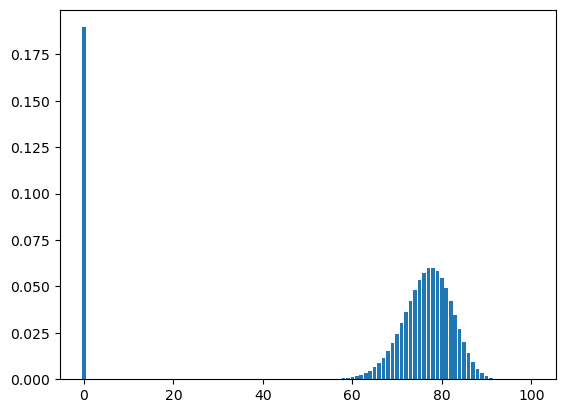

In [4]:
plt.bar(Pos, np.exp(log_pi))
plt.show()

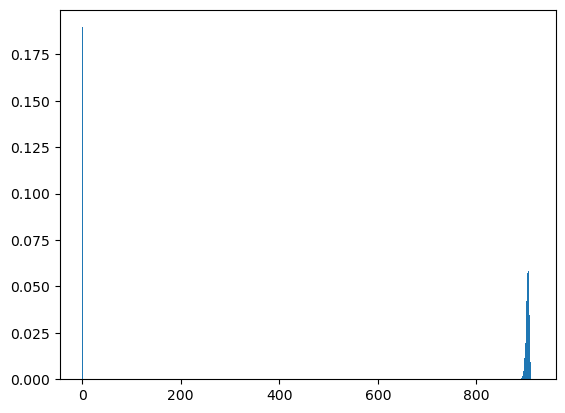

In [5]:
plt.bar(cps, np.exp(log_pi))
plt.show()

In [6]:
cs = 0.2
N = 100
Pos = np.arange(0, N+1)
kr = params.tau_ps * params.Jmax / params.vp

cjsrs = np.linspace(875, 1000, num=2000)
cp_means = np.zeros(2000)
cp_stds = np.zeros(2000)

for i in range(2000):
    log_pi = Po_stationary_logp(N, cs, cjsrs[i], params)
    cps = (cs + kr * cjsr * Pos) / (1 + kr * Pos)
    cp_means[i] = np.sum(cps * np.exp(log_pi))
    cp_stds[i] = np.sqrt(np.sum(cps**2 * np.exp(log_pi)) - cp_means[i])

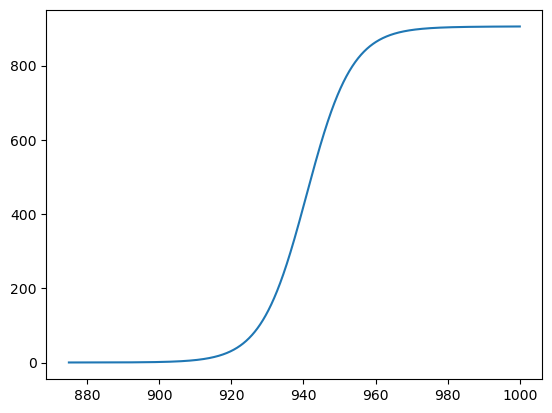

In [7]:
plt.plot(cjsrs, cp_means)
plt.show()

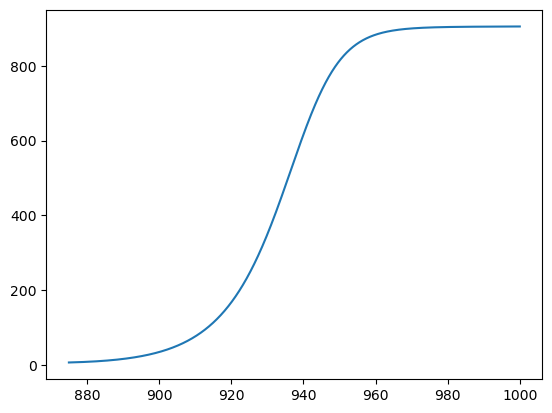

In [8]:
plt.plot(cjsrs, cp_stds)
plt.show()

In [9]:
N = 100
init_gillespie = np.array([N, 0, 0, 0])
init_diff = np.array([1.0, 0, 0, 0])
cs = 0.2
cjsr = 1100.

eps = 1 / np.sqrt(N)

In [46]:
ts_g, ryr_g, mgle = ryr_gillespie_and_martingale(init_gillespie, cs, cjsr, params, nstep=100_000)

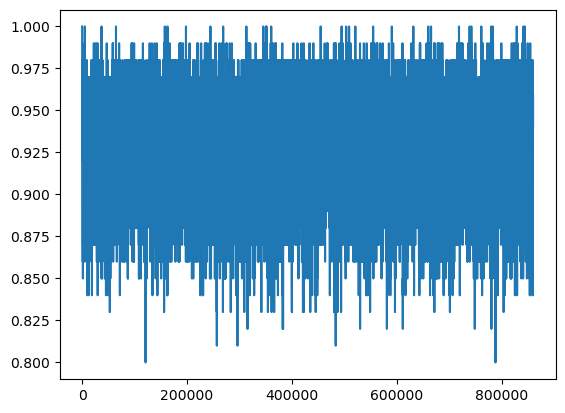

In [47]:
plt.plot(ts_g, ryr_g[:, 0] / N)
plt.show()

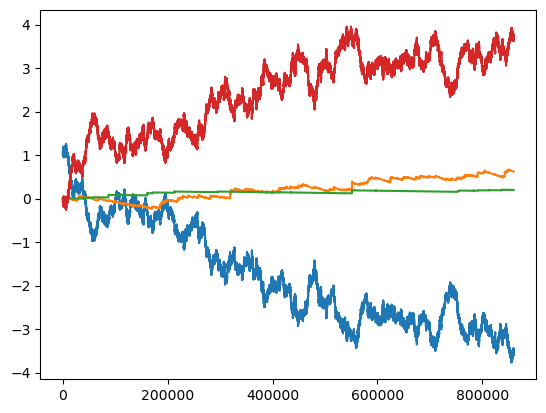

In [48]:
plt.plot(ts_g, mgle[:, 0])
plt.plot(ts_g, mgle[:, 1])
plt.plot(ts_g, mgle[:, 2])
plt.plot(ts_g, mgle[:, 3])
plt.show()

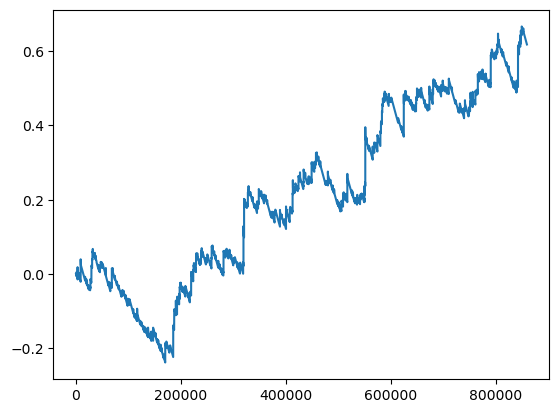

In [50]:
plt.plot(ts_g, mgle[:, 1])
plt.show()

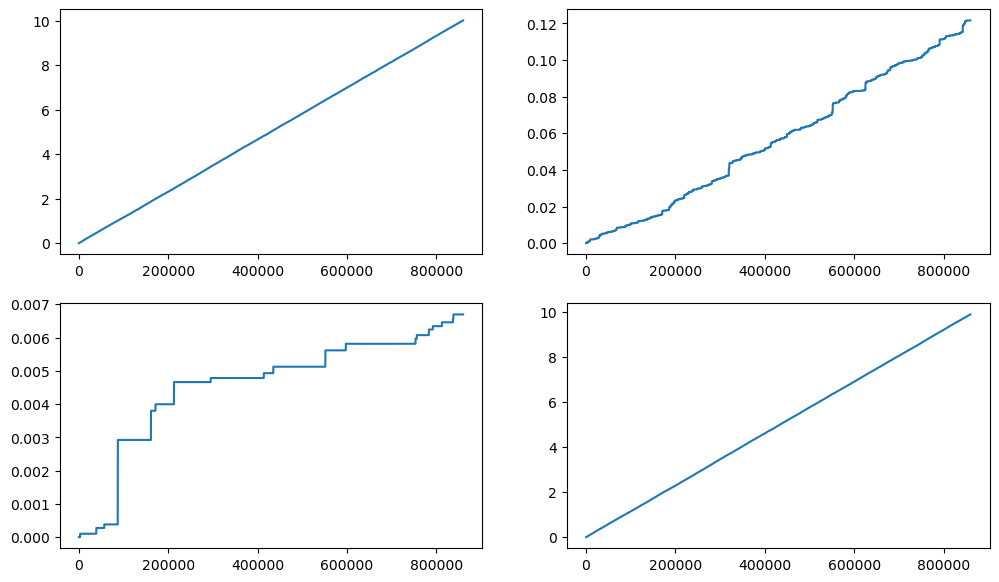

In [52]:
fig, ax = plt.subplots(2, 2, figsize=(12, 7))
ax[0,0].plot(ts_g[1:], np.cumsum((mgle[1:, 0] - mgle[:-1, 0])**2))
ax[0,1].plot(ts_g[1:], np.cumsum((mgle[1:, 1] - mgle[:-1, 1])**2))
ax[1,0].plot(ts_g[1:], np.cumsum((mgle[1:, 2] - mgle[:-1, 2])**2))
ax[1,1].plot(ts_g[1:], np.cumsum((mgle[1:, 3] - mgle[:-1, 3])**2))
plt.show()

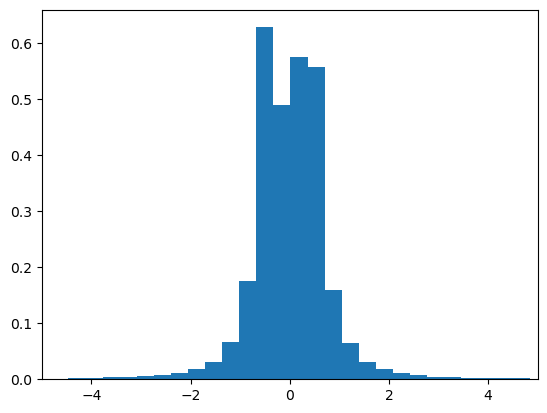

In [73]:
#fig, ax = plt.subplots(2, 2, figsize=(12, 7))
plt.hist(100*(mgle[1:, 0] - mgle[:-1, 0]) / np.sqrt(ts_g[1:] - ts_g[:-1]), bins=2000, density=True)
plt.xlim(-5, 5)
#ax[0,1].hist((mgle[1:, 1] - mgle[:-1, 1]), bins=100)
#ax[1,0].hist((mgle[1:, 2] - mgle[:-1, 2]), bins=100)
#ax[1,1].hist((mgle[1:, 3] - mgle[:-1, 3]), bins=100)
plt.show()

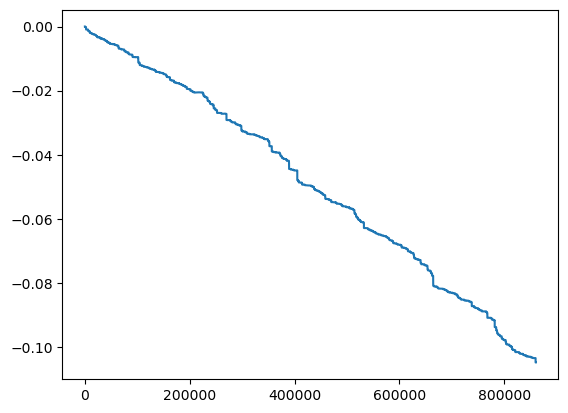

In [14]:
plt.plot(ts_g[1:], np.cumsum((mgle[1:, 0] - mgle[:-1, 0])*(mgle[1:, 1] - mgle[:-1, 1])))
plt.show()

In [31]:
ts_g, ryr_g = ryr_gillespie(init_gillespie, cs, cjsr, params, nstep=1_000)

In [32]:
ts_g_, ryr_g_, cp_ = ryr_gillespie_homog(init_gillespie, cs, cjsr, cs, params, nstep=8_000_000)

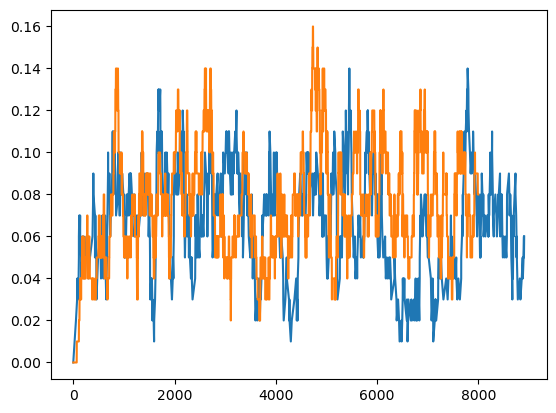

In [33]:
plt.plot(ts_g, ryr_g[:, 3] / 100)
plt.plot(ts_g_, ryr_g_[:, 3] / 100)
plt.show()

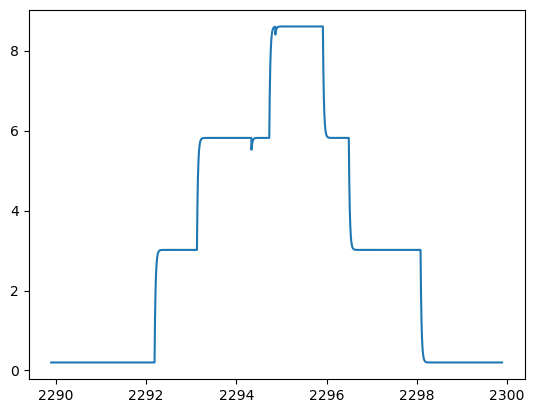

In [45]:
plt.plot(ts_g_[2290000:2300000], cp_[2290000:2300000])
plt.show()

In [19]:
ts_d, ryr_d = ryr_diffusion(init_diff, cs, cjsr, eps, params, 8_000_000, 1e-3)
ts_d_, ryr_d_ = ryr_diffusion_penalised_qv(init_diff, cs, cjsr, eps, params, 8_000_000, 1e-3)
ts_g, ryr_g = ryr_gillespie(init_gillespie, cs, cjsr, params, nstep=1_000)

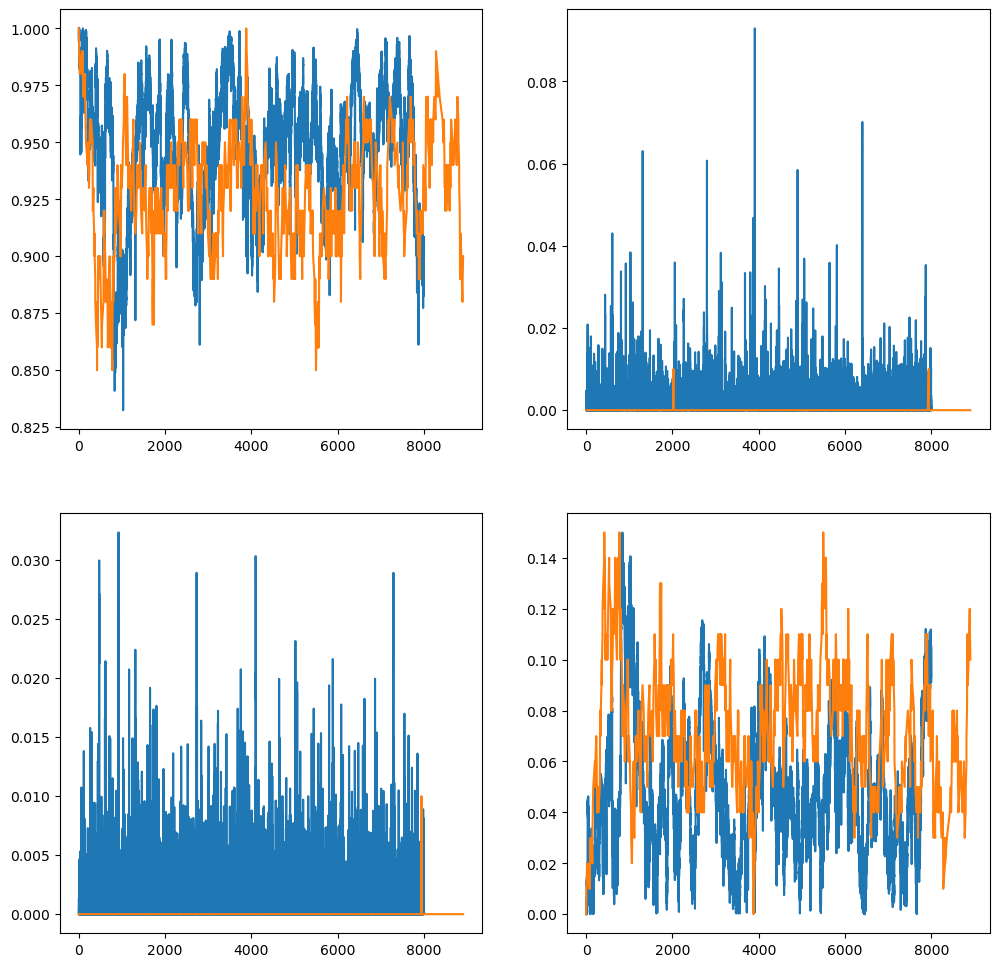

In [20]:
fig, ax = plt.subplots(2,2, figsize=(12,12))
ax[0,0].plot(ts_d[::100], ryr_d[::100, 0])
ax[0,0].plot(ts_g, ryr_g[:, 0] / N)

ax[0,1].plot(ts_d[::100], ryr_d[::100, 1])
ax[0,1].plot(ts_g, ryr_g[:, 1] / N)

ax[1,0].plot(ts_d[::100], ryr_d[::100, 2])
ax[1,0].plot(ts_g, ryr_g[:, 2] / N)

ax[1,1].plot(ts_d[::100], ryr_d[::100, 3])
ax[1,1].plot(ts_g, ryr_g[:, 3] / N)
plt.show()

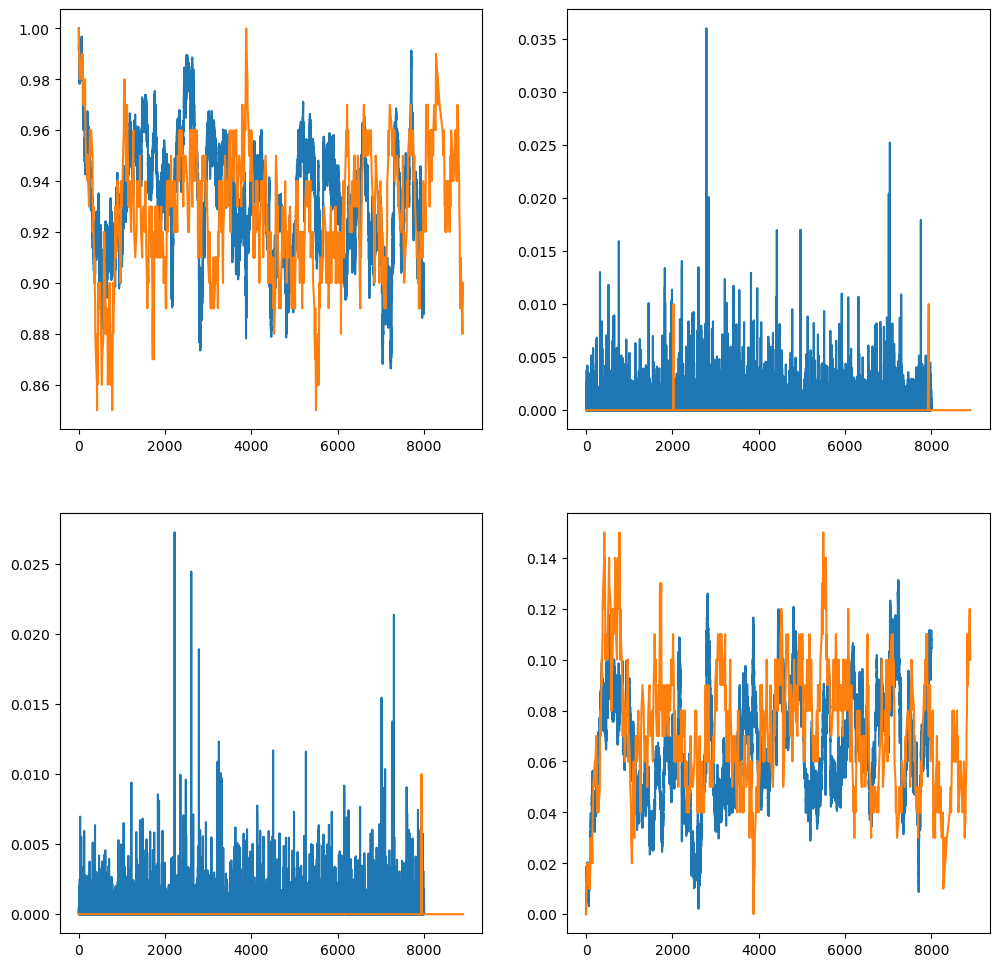

In [21]:
fig, ax = plt.subplots(2,2, figsize=(12,12))
ax[0,0].plot(ts_d_[::100], ryr_d_[::100, 0])
ax[0,0].plot(ts_g, ryr_g[:, 0] / N)

ax[0,1].plot(ts_d_[::100], ryr_d_[::100, 1])
ax[0,1].plot(ts_g, ryr_g[:, 1] / N)

ax[1,0].plot(ts_d_[::100], ryr_d_[::100, 2])
ax[1,0].plot(ts_g, ryr_g[:, 2] / N)

ax[1,1].plot(ts_d_[::100], ryr_d_[::100, 3])
ax[1,1].plot(ts_g, ryr_g[:, 3] / N)
plt.show()

In [23]:
kr = params.tau_ps * params.Jmax / params.vp
cp_g = (cs + cjsr * kr * (ryr_g[:, 1] + ryr_g[:, 2]) / N) / (1 + kr * (ryr_g[:, 1] + ryr_g[:, 2]) / N)
cp_d = (cs + cjsr * kr * (ryr_d[:, 1] + ryr_d[:, 2])) / (1 + kr * (ryr_d[:, 1] + ryr_d[:, 2]))
cp_d_ = (cs + cjsr * kr * (ryr_d_[:, 1] + ryr_d_[:, 2])) / (1 + kr * (ryr_d_[:, 1] + ryr_d_[:, 2]))

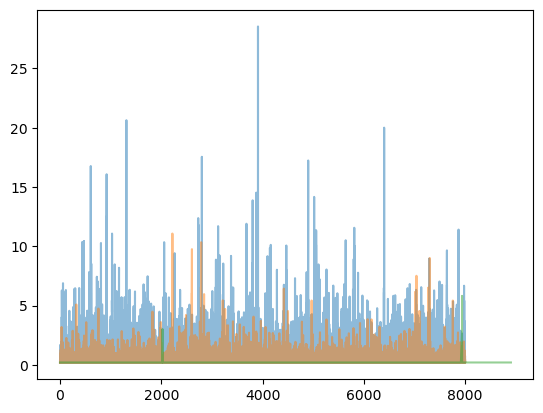

In [24]:
plt.plot(ts_d[::100], cp_d[::100], alpha=0.5)
plt.plot(ts_d_[::100], cp_d_[::100], alpha=0.5)
plt.plot(ts_g, cp_g, alpha=0.5)
plt.show()